# L1: ODE Solving for Reactor Modeling

Reactor models frequently reduce to systems of ordinary differential equations (ODEs). For **batch reactors** and **plug-flow reactors** all spatial gradients vanish or are replaced by the residence time coordinate. This notebook demonstrates how to formulate and solve such models using explicit and implicit methods in Python.

## Governing equations

A multicomponent reacting system with $n_c$ species and $n_r$ reactions:

$$\frac{d\mathbf{c}}{dt} = \boldsymbol{\nu}^T \mathbf{r}(\mathbf{c}, T)$$

$$\frac{dT}{dt} = -\frac{\boldsymbol{\Delta H}^T \mathbf{r}(\mathbf{c}, T)}{\rho c_p}$$

where $\boldsymbol{\nu}$ is the $(n_r \times n_c)$ stoichiometric matrix, $\mathbf{r}$ the vector of reaction rates, and $\Delta H_j$ the heat of reaction $j$.

The stoichiometric matrix encodes mass conservation; each column sums to zero for closed systems.

**Forward (explicit) Euler** — first-order, conditionally stable:

$$\mathbf{c}^{n+1} = \mathbf{c}^n + \Delta t\, \mathbf{f}(\mathbf{c}^n)$$

**Backward (implicit) Euler** — first-order, unconditionally stable (A-stable):

$$\mathbf{c}^{n+1} = \mathbf{c}^n + \Delta t\, \mathbf{f}(\mathbf{c}^{n+1})$$

The implicit step requires solving a nonlinear system at each time level.

## PyMRM building blocks

| Function / module | Role |
|---|---|
| `scipy.integrate.solve_ivp` | Adaptive Runge–Kutta integration (BDF for stiff systems) |
| `pymrm.NumJac` | Finite-difference Jacobian approximation |
| `pymrm.newton` | Newton–Raphson solver for nonlinear systems |
| `numpy` stoichiometric matrix | Encodes reaction network; `nu @ r(c)` gives rate vector |

## Example 1 — Consecutive reactions A → B → C in a batch reactor

Parameters: $k_1 = 1\,\text{s}^{-1}$, $k_2 = 0.5\,\text{s}^{-1}$, $c_{A,0} = 1\,\text{mol/m}^3$.

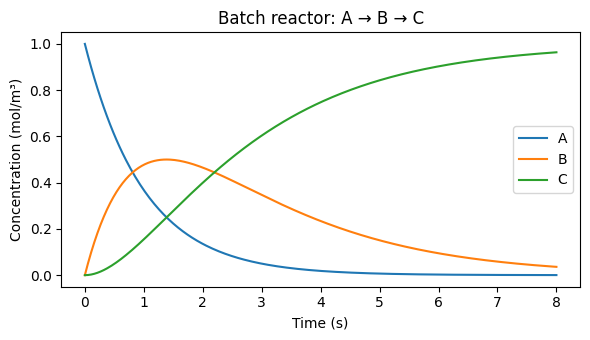

Maximum B concentration: 0.5000 at t = 1.39 s


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

k1, k2 = 1.0, 0.5          # rate constants [1/s]
nu = np.array([[-1, 0],     # stoichiometric matrix (nc x nr)
               [ 1,-1],
               [ 0, 1]])

def rates(c): return np.array([k1*c[0], k2*c[1]])
def rhs(t, c): return nu @ rates(c)

c0 = np.array([1.0, 0.0, 0.0])
sol = solve_ivp(rhs, [0, 8], c0, dense_output=True, rtol=1e-8)

t = np.linspace(0, 8, 300)
C = sol.sol(t)
plt.figure(figsize=(6, 3.5))
for i, label in enumerate(['A', 'B', 'C']):
    plt.plot(t, C[i], label=label)
plt.xlabel('Time (s)'); plt.ylabel('Concentration (mol/m³)')
plt.title('Batch reactor: A → B → C')
plt.legend(); plt.tight_layout(); plt.show()
print(f'Maximum B concentration: {C[1].max():.4f} at t = {t[C[1].argmax()]:.2f} s')

## Example 2 — Stiff system: explicit vs implicit Euler

A stiff system has widely separated time scales. Here $k_1 = 1$ and $k_2 = 1000\,\text{s}^{-1}$ to create stiffness. The explicit Euler method requires $\Delta t < 1/k_2 = 10^{-3}\,\text{s}$ for stability, while backward Euler remains stable with much larger time steps.

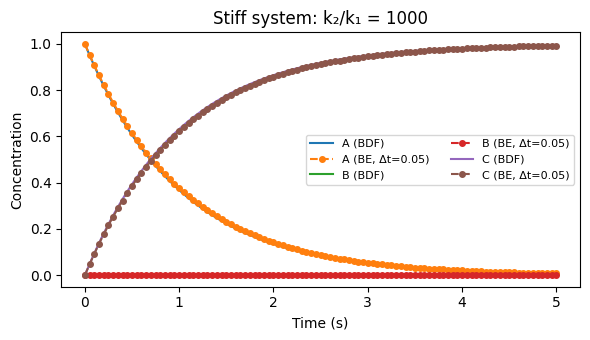

In [ ]:
from scipy import sparse
from pymrm import NumJac, newton

k1_s, k2_s = 1.0, 1000.0
nu_s = np.array([[-1, 0], [1, -1], [0, 1]])

def rhs_s(c): return nu_s @ np.array([k1_s*c[0], k2_s*c[1]])

# Backward Euler with Newton solve
dt = 0.05   # large step — stable for implicit, unstable for explicit
t_end = 5.0
t_be, c_be = [0.0], [np.array([1.0, 0.0, 0.0])]
c = c_be[0].copy()
t = 0.0
numjac = NumJac(c.shape)
while t < t_end - 1e-10:
    c_old = c.copy()
    def residual(c_new):
        g = c_new - c_old - dt * rhs_s(c_new)
        _, jac_rhs = numjac(rhs_s, c_new)
        jac = sparse.eye(len(c_new), format='csc') - dt * jac_rhs
        return g.reshape(-1, 1), jac
    result = newton(residual, c.copy())
    c = result.x.ravel()
    t += dt; t_be.append(t); c_be.append(c.copy())

t_be = np.array(t_be)
c_be = np.array(c_be)

# Reference: solve_ivp (BDF)
sol_ref = solve_ivp(lambda t, c: rhs_s(c), [0, t_end],
                    [1.0, 0.0, 0.0], method='BDF', dense_output=True)
t_ref = np.linspace(0, t_end, 500)
C_ref = sol_ref.sol(t_ref)

fig, ax = plt.subplots(figsize=(6, 3.5))
for i, lab in enumerate(['A', 'B', 'C']):
    ax.plot(t_ref, C_ref[i], lw=1.5, label=f'{lab} (BDF)')
    ax.plot(t_be, c_be[:, i], 'o--', ms=4, label=f'{lab} (BE, Δt={dt})')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Concentration')
ax.set_title(f'Stiff system: k₂/k₁ = {k2_s/k1_s:.0f}')
ax.legend(ncol=2, fontsize=8); plt.tight_layout(); plt.show()


## Summary

| Method | Order | Stability | Recommended for |
|---|---|---|---|
| Forward Euler | 1 | Conditional ($\Delta t < 2/\lambda_{\max}$) | Non-stiff, simple |
| Backward Euler | 1 | Unconditional (A-stable) | Stiff systems, moderate accuracy |
| `solve_ivp` RK45 | 4/5 | Conditional (adaptive) | Non-stiff, high accuracy |
| `solve_ivp` BDF | 1–5 | Stiff-safe (adaptive) | Stiff chemical kinetics |

**Key insight**: The stoichiometric matrix $\boldsymbol{\nu}$ is the central data structure. Defining it once lets you swap reaction networks without rewriting the integrator.